<font size="4"><b>1. Clustering<b></font>

(1) K-means Algorithm:

Step 0: Randomly initialize K Cluster centroids (center of cluster): $\mu_{1}, \mu_{2} ..., \mu_{k}$.

Repeat{

Step 1: Assign each point to its closest cluster centroid:

for i = 1 to m

$𝑐^{(𝑖)}=$  index (from 1 to K) of cluster centroid closest to  $𝑥^{(𝑖)}$

$\min_{k}|𝑥^{(𝑖)}−\mu_{𝑘}|^{2} $

Step 2: Move cluster centroids:

for  𝑘=1  to K

$\mu_{𝑘}$ : = average of points assigned to cluster k.

}

Repete Step 1 and 2 until no more changes, converge.

If a cluster has 0 training samples assigned to it. Eliminite that cluster.

(2) K-means Optimization objective

Cost function for K-means

$J(c^{(1)}, ..., c^{(m)}, \mu_{1}, ..., \mu_{k}) = \frac{1}{m}\sum_{i=1}^{m} |x^{(i)} - \mu_{c^{(i)}}|^{2}$ (distortions)

(3) Initializing K-means

Choose K < m. Randomly pick K training examples. Set $\mu_{1}, \mu_{2} ..., \mu_{k}$ equal to these K examples.

Try multiple initial guesses. Compute cost function J for each guess, compare and choose the lowest.

(4) Choosing the number of clusters K

1. Elbow method: draw a graph, x-axis is K(number of clusters) and y-axis is the cost function J. Choose the point as K where the J function starts to decrease slowly, which is the elbow.

2. Evaluate what K-means based on how well it performs on the later purpose.


<font size="4"><b>2. Anomaly Detection<b></font>

Example:

Aircraft engine features:

$x_{1}$ = heat generated

$x_{2}$ = vibration intensity

...

Dataset: $\{x^{(1)}, x^{(2)}, ..., x^{(m)}$\}. Is $x_{test}$ anomalous?

2.1 Density Estimation

Probability of x being seen in the dataset $p(x)$. Compute the probability of $p(x_{test}) < \epsilon$. If it is small, raise a flag of anomaly.

Fraud detection:

$x^{(i)} = $ features of user $i's$ activities: how often log in? how many web pages visited? transactions? posts? typing speed?

Model $p(x)$ from data

Identify unusual users by checking which have $p(x)<\epsilon$

2.2 Gaussian (normal) distribution

Parameter estimate: $\mu, \sigma^{2}$, given dataset $\{x^{(1)}, x^{(2)}, ..., x^{(m)}$\}.

$\mu = \frac{1}{m} \sum_{i=1}^{m}x^{(i)}$

$\sigma^{2} = \frac{1}{m} \sum_{i=1}^{m} (x^{(i)}-\mu)^{2}$ (or divide by $m-1$ instead of $m$)

This is Maximum Likelihood estimation

2.3 Anomaly detection algorithm

Density estimation

Training set: $\{\vec{x}^{(1)}, \vec{x}^{(2)}, ..., \vec{x}^{(m)}$\}, each example $\vec{x}^{(i)}$has n features.

Estimate $p(\vec{x})$ for any given feature vector: treat as independent features

$p(\vec{x}) = p(x_{1}; \mu_{1}, \sigma^{2}_{1}) * p(x_{2}; \mu_{2}, \sigma^{2}_{2}) * p(x_{3}; \mu_{3}, \sigma^{2}_{3}) * ...* p(x_{n}; \mu_{n}, \sigma^{2}_{n}) = \Pi_{j=1}^{n} p(x_{j}; \mu_{j}, \sigma^{2}_{j})$

(1) Choose n features $x_{i}$ that you think is indicative of anomalous examples.

(2) Fit parameters $\mu_{1}, ...\mu_{n}, \sigma^{2}_{1}, ..., \sigma^{2}_{n}$.

$\mu_{j} = \frac{1}{m} \sum_{i=1}^{m}x^{(i)}_{j}$

$\sigma^{2}_{j} = \frac{1}{m} \sum_{i=1}^{m} (x^{(i)}_{j}-\mu_{j})^{2}$

(3) Given new example x, compute $p(x)$:
\begin{equation}
p(x) = \Pi_{j=1}^{n}p(x_{j};\mu_{j},\sigma^{2}_{j}) = \Pi_{j=1}^{n}\frac{1}{\sqrt{2\pi}\sigma_{j}} exp \big(- \frac{(x_{j}-\mu_{j})^{2}}{2\sigma^{2}_{j}}\big)
\end{equation}

Anomaly if $p(x) <\epsilon$

2.4 Develop and evaluate an anomaly detection system

Real-number evaluation: a way to evaluate our learning alogorithm

Assume we have some labelde data, of anomalous (y=1) and non-anomalous (y=0) examples. A dataset with 10,000 good engines and 20 flawed engines.

(1) Training set: 6000 good engines. Train algorithm on the training set, get $\mu$ and $\sigma^{2}$. Because training set only contains negative examples, it is unsuprivised learning.

(2) Cross validation set: 2000 good engines (y=0), 10 anomalous (y=1). See how many of the anomalous engines are correctly flags. Use CV set to tune the $\epsilon$.

(3) Test set: 2000 good engines (y=0), 10 anomalous (y=1). Evaluate on the test set, false positive and false negative, precision, recall, F1-score.

Alternative: no test set (if not enough data for anomaly), has a risk of overfit.

2.4 Anomalty detection VS. Supervised learning

(1) Anomalty detection: very small number of positive examples (y=1) (0-20 is common). Large number of negative (y=0) examples to learn $p(x)$, that $p(x)$ are only learned from the negative examples. The small number of positive examples are only used in the CV set and test set for parameter tuning and evaluation.

Many different 'types' of anomalies. Hard for any algorithm to learn from positive examples what anomalies look like; future anomalies may look nothing like any of the existing anomalous examples we've seen so far.

Example: Financial fraud (fraud detection), Manufacturing - finding new previously unseen defects (aircraft engines), Monitoring machines in a data center ...

(2) Supervised learning: large number of positive and negative examples.

Enough positive examples for algorithm to get a sense of what positive examples are like, future positive examples likely to be similar ro ones in training set.

Example: Email spam classification, Manufacturing - finding known previously seen defects, Weather prediction, Disease classification ...

2.5 Choosing what features to use

In Supervised learning, if you don't have features uite right, or if you hae features that are not revelant to the problem, that often turns out to be okay. It is crutial for unsupervised learning

(1) Non-gaussian features: transform to Gaussian

Take log: np.log(x), np.log(x+1), np.log(x+c)

Take root: $x^{1/2}, x^{1/3}$

(2) Error analysis for anomaly detection

Want $p(x)>\epsilon$ to be large for normal exapmles x, and $p(x)<\epsilon$ to be small for anomalous examples x.

If you have an example in CV set or test test that is anomaly, but has a pretty high $p(x)$. I will try to look at that example and try to figure out what is that made me think is an anomoly. If I can identify some new feature, then adding that feature can help improve performance of the algorithm.

Choose features that may take on unusually large or small values in the eventof an anomaly. A combination of old features to become a new feature may be a case.

For example, a high CPU load combined with a low network traffic is unusual. Create a new feature $x = \frac{CPU load}{network traffic}$ or $x = \frac{(CPU load)^{2}}{network traffic}$

(array([ 58., 350., 676., 634., 660., 633., 582., 572., 597., 512., 507.,
        492., 406., 396., 356., 338., 331., 272., 214., 216., 186., 160.,
        131., 117., 104.,  73.,  90.,  71.,  56.,  41.,  49.,  31.,  13.,
         21.,  12.,   7.,   5.,   9.,   7.,   1.,   6.,   2.,   1.,   1.,
          1.,   1.,   1.,   0.,   0.,   1.]),
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
         22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
         44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
         66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
         88.,  90.,  92.,  94.,  96.,  98., 100.]),
 <BarContainer object of 50 artists>)

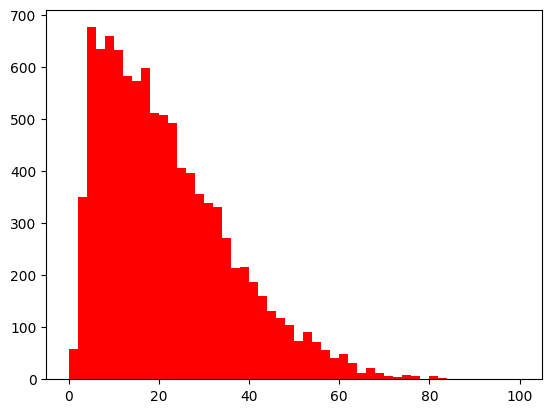

In [ ]:
# make skewed dataset
from scipy.stats import skewnorm
import matplotlib.pyplot as plt

numValues = 10000
maxValue = 100
skewness = 20. #Negative values are left skewed, positive values are right skewed

random = skewnorm.rvs(a = skewness, loc = maxValue, size= numValues)

random = random - min(random)
random = random / max(random)
random = random * maxValue

x = random

# plot histgram to check skewness
plt.hist(x, bins = 50, color = 'r')

(array([  1.,   0.,   0.,   0.,   0.,   1.,   3.,   2.,   9.,  28.,  33.,
         66., 125., 186., 272., 287., 313., 312., 373., 403., 442., 400.,
        413., 484., 522., 473., 490., 513., 457., 445., 414., 431., 389.,
        310., 292., 257., 195., 174., 138., 111.,  86.,  64.,  37.,  14.,
         17.,   8.,   5.,   2.,   2.,   1.]),
 array([0.        , 0.12619147, 0.25238294, 0.37857441, 0.50476588,
        0.63095734, 0.75714881, 0.88334028, 1.00953175, 1.13572322,
        1.26191469, 1.38810616, 1.51429763, 1.6404891 , 1.76668056,
        1.89287203, 2.0190635 , 2.14525497, 2.27144644, 2.39763791,
        2.52382938, 2.65002085, 2.77621232, 2.90240378, 3.02859525,
        3.15478672, 3.28097819, 3.40716966, 3.53336113, 3.6595526 ,
        3.78574407, 3.91193554, 4.038127  , 4.16431847, 4.29050994,
        4.41670141, 4.54289288, 4.66908435, 4.79527582, 4.92146729,
        5.04765876, 5.17385022, 5.30004169, 5.42623316, 5.55242463,
        5.6786161 , 5.80480757, 5.93099904, 6.

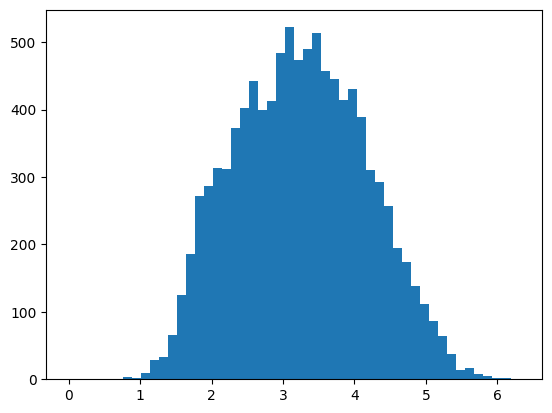

In [ ]:
plt.hist(x**0.4, bins = 50)

In [ ]:
xNew = x ** 0.4

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 2.000e+00, 2.000e+00,
        6.000e+00, 1.400e+01, 3.100e+01, 5.000e+01, 1.010e+02, 1.940e+02,
        3.440e+02, 4.370e+02, 5.160e+02, 6.780e+02, 8.020e+02, 9.370e+02,
        1.137e+03, 1.262e+03, 1.189e+03, 1.082e+03, 7.190e+02, 3.880e+02,
        9.200e+01, 1.400e+01]),
 array([-6.90775528e+00, -6.67749657e+00, -6.44723786e+00, -6.21697915e+00,
        -5.98672044e+00, -5.75646173e+00, -5.52620302e+00, -5.29594431e+00,
        -5.06568560e+00, -4.83542690e+00, -4.60516819e+00, -4.37490948e+00,
        -4.14465077e+00, -3.91439206e+00, -3.68413335e+00, -3.45387464e+00,
        -3.22361593e+00, -2.99335722e+00, -2.76309851e+00, -2.53283980e+

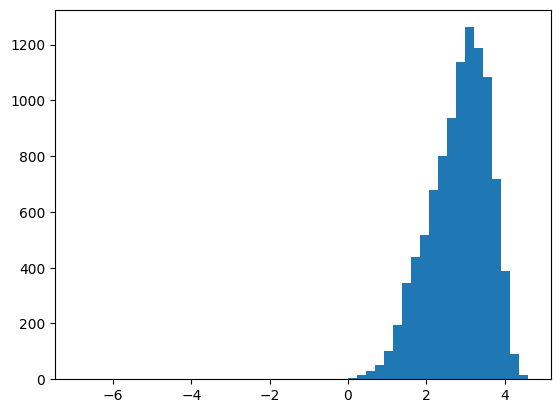

In [ ]:
import numpy as np
plt.hist(np.log(x+0.001), bins = 50)   # min(x) = 0, and log0 is not defined, so add a small number

(array([  1.,   4.,   4.,  16.,  33.,  45.,  64., 116., 153., 198., 213.,
        213., 233., 242., 249., 266., 294., 330., 307., 296., 322., 355.,
        363., 400., 362., 374., 398., 417., 355., 380., 363., 350., 375.,
        326., 263., 248., 238., 183., 166., 137., 110.,  89.,  63.,  38.,
         16.,  17.,   8.,   3.,   3.,   1.]),
 array([1.79175947, 1.84919306, 1.90662665, 1.96406025, 2.02149384,
        2.07892743, 2.13636102, 2.19379462, 2.25122821, 2.3086618 ,
        2.36609539, 2.42352899, 2.48096258, 2.53839617, 2.59582976,
        2.65326336, 2.71069695, 2.76813054, 2.82556413, 2.88299773,
        2.94043132, 2.99786491, 3.0552985 , 3.1127321 , 3.17016569,
        3.22759928, 3.28503287, 3.34246647, 3.39990006, 3.45733365,
        3.51476724, 3.57220084, 3.62963443, 3.68706802, 3.74450161,
        3.80193521, 3.8593688 , 3.91680239, 3.97423598, 4.03166958,
        4.08910317, 4.14653676, 4.20397035, 4.26140395, 4.31883754,
        4.37627113, 4.43370472, 4.49113832, 4.

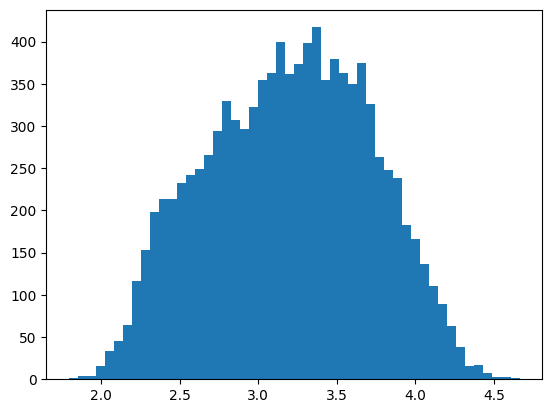

In [ ]:
# to make it more Gaussian
plt.hist(np.log(x+6), bins = 50)